In [ ]:
import pandas as pd

# Load the dataset
file_path = "Obesity prediction.csv"
df = pd.read_csv(file_path)

# Display basic information about the dataset
df.info()

# Show the first few rows
df.head()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2111 entries, 0 to 2110
Data columns (total 17 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Gender          2111 non-null   object 
 1   Age             2111 non-null   float64
 2   Height          2111 non-null   float64
 3   Weight          2111 non-null   float64
 4   family_history  2111 non-null   object 
 5   FAVC            2111 non-null   object 
 6   FCVC            2111 non-null   float64
 7   NCP             2111 non-null   float64
 8   CAEC            2111 non-null   object 
 9   SMOKE           2111 non-null   object 
 10  CH2O            2111 non-null   float64
 11  SCC             2111 non-null   object 
 12  FAF             2111 non-null   float64
 13  TUE             2111 non-null   float64
 14  CALC            2111 non-null   object 
 15  MTRANS          2111 non-null   object 
 16  Obesity         2111 non-null   object 
dtypes: float64(8), object(9)
memory u

,Gender,Age,Height,Weight,family_history,FAVC,FCVC,NCP,CAEC,SMOKE,CH2O,SCC,FAF,TUE,CALC,MTRANS,Obesity
0,Female,21.0,1.62,64.0,yes,no,2.0,3.0,Sometimes,no,2.0,no,0.0,1.0,no,Public_Transportation,Normal_Weight
1,Female,21.0,1.52,56.0,yes,no,3.0,3.0,Sometimes,yes,3.0,yes,3.0,0.0,Sometimes,Public_Transportation,Normal_Weight
2,Male,23.0,1.80,77.0,yes,no,2.0,3.0,Sometimes,no,2.0,no,2.0,1.0,Frequently,Public_Transportation,Normal_Weight
3,Male,27.0,1.80,87.0,no,no,3.0,3.0,Sometimes,no,2.0,no,2.0,0.0,Frequently,Walking,Overweight_Level_I
4,Male,22.0,1.78,89.8,no,no,2.0,1.0,Sometimes,no,2.0,no,0.0,0.0,Sometimes,Public_Transportation,Overweight_Level_II


In [ ]:
from sklearn.preprocessing import LabelEncoder, StandardScaler

# Encoding categorical variables
categorical_columns = ['Gender', 'family_history', 'FAVC', 'CAEC', 'SMOKE', 'SCC', 'CALC', 'MTRANS', 'Obesity']
label_encoders = {}

for col in categorical_columns:
    le = LabelEncoder()
    df[col] = le.fit_transform(df[col])
    label_encoders[col] = le  # Storing the encoders for reference

# Scaling numerical variables
numerical_columns = ['Age', 'Height', 'Weight', 'FCVC', 'NCP', 'CH2O', 'FAF', 'TUE']
scaler = StandardScaler()
df[numerical_columns] = scaler.fit_transform(df[numerical_columns])

# Checking dataset after preprocessing
df.head()


,Gender,Age,Height,Weight,family_history,FAVC,FCVC,NCP,CAEC,SMOKE,CH2O,SCC,FAF,TUE,CALC,MTRANS,Obesity
0,0,-0.522124,-0.875589,-0.862558,1,0,-0.785019,0.404153,2,0,-0.013073,0,-1.188039,0.561997,3,3,1
1,0,-0.522124,-1.947599,-1.168077,1,0,1.088342,0.404153,2,1,1.618759,1,2.339750,-1.080625,2,3,1
2,1,-0.206889,1.054029,-0.366090,1,0,-0.785019,0.404153,2,0,-0.013073,0,1.163820,0.561997,1,3,1
3,1,0.423582,1.054029,0.015808,0,0,1.088342,0.404153,2,0,-0.013073,0,1.163820,-1.080625,1,4,5
4,1,-0.364507,0.839627,0.122740,0,0,-0.785019,-2.167023,2,0,-0.013073,0,-1.188039,-1.080625,2,3,6


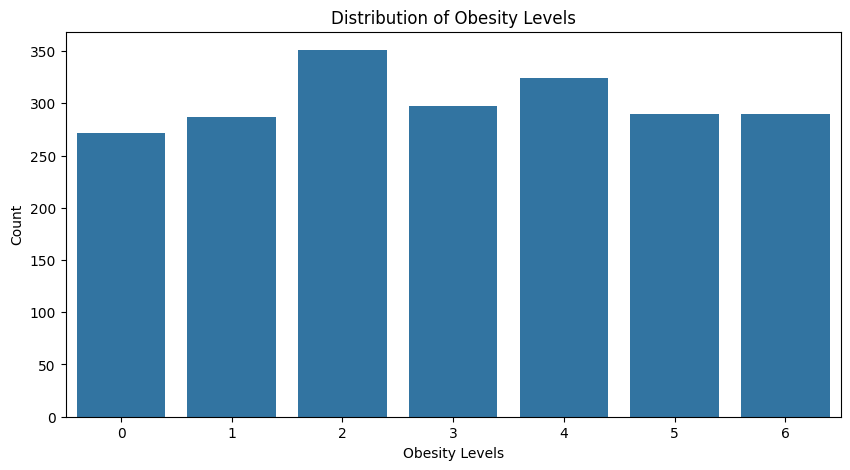

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Plot the distribution of the target variable (Obesity levels)
plt.figure(figsize=(10, 5))
sns.countplot(x=df["Obesity"])
plt.xlabel("Obesity Levels")
plt.ylabel("Count")
plt.title("Distribution of Obesity Levels")
plt.show()


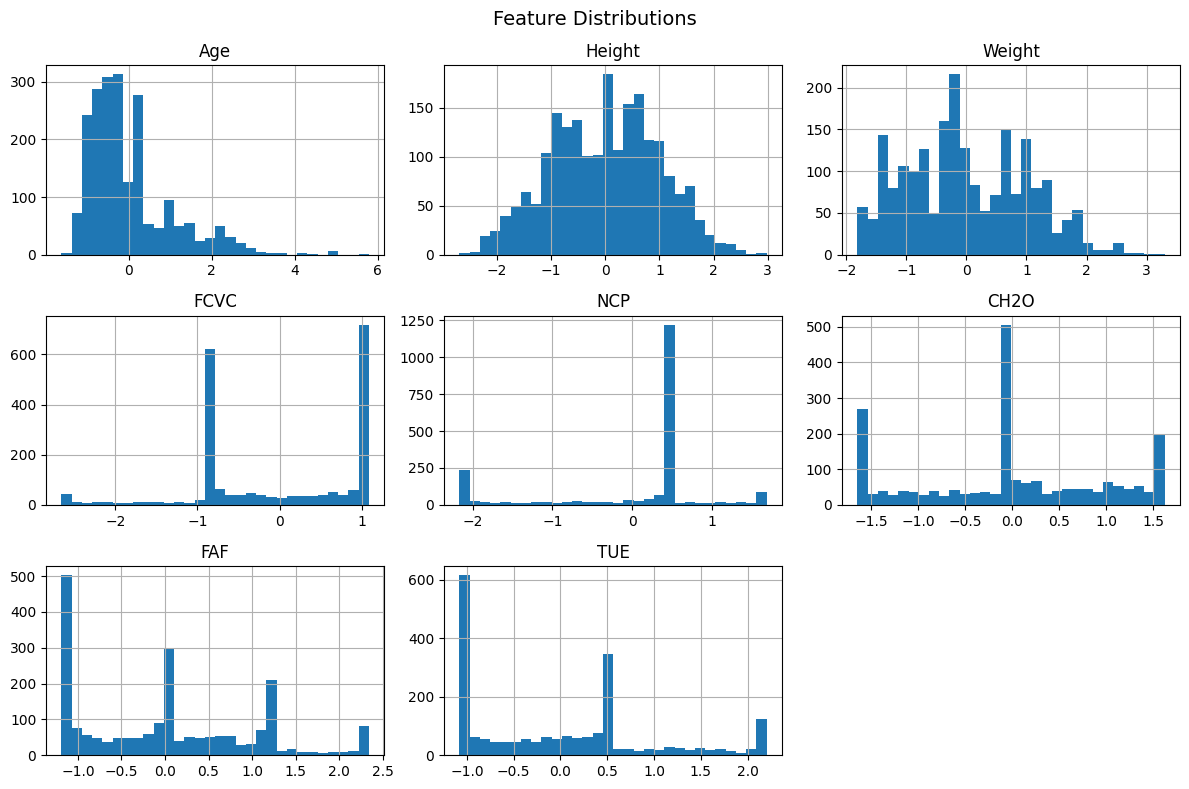

In [ ]:
# Plot distributions of numerical features
df[numerical_columns].hist(figsize=(12, 8), bins=30, layout=(3, 3))
plt.suptitle("Feature Distributions", fontsize=14)
plt.tight_layout()
plt.show()


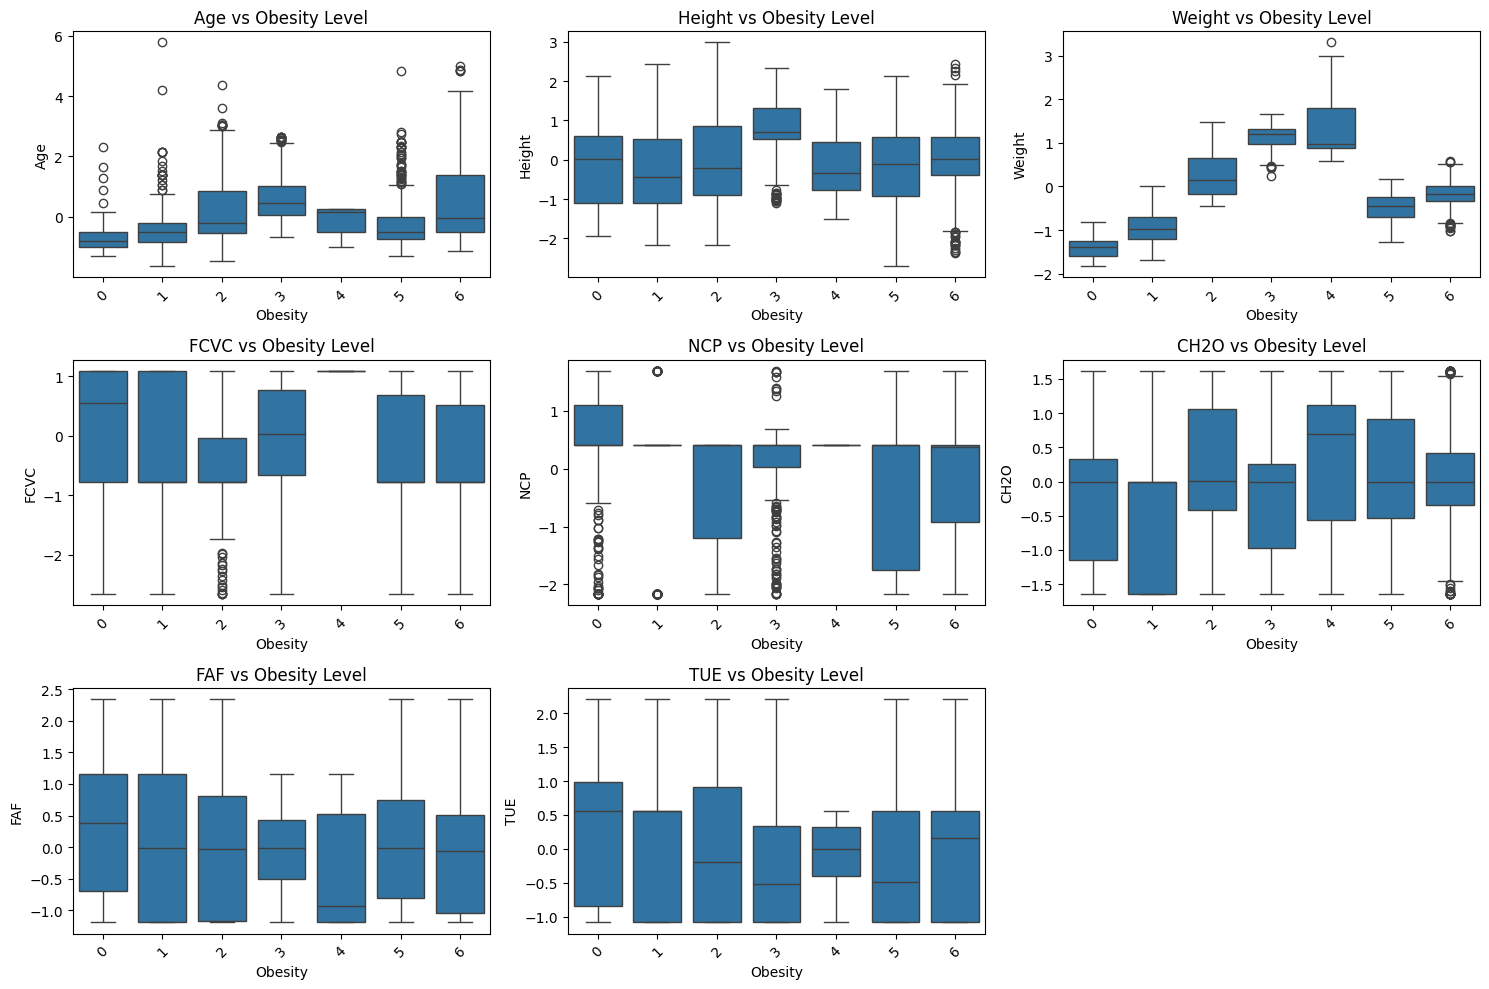

In [ ]:
# Boxplots of numerical features against obesity levels
plt.figure(figsize=(15, 10))
for i, col in enumerate(numerical_columns, 1):
    plt.subplot(3, 3, i)
    sns.boxplot(x=df["Obesity"], y=df[col])
    plt.xticks(rotation=45)
    plt.title(f"{col} vs Obesity Level")
plt.tight_layout()
plt.show()


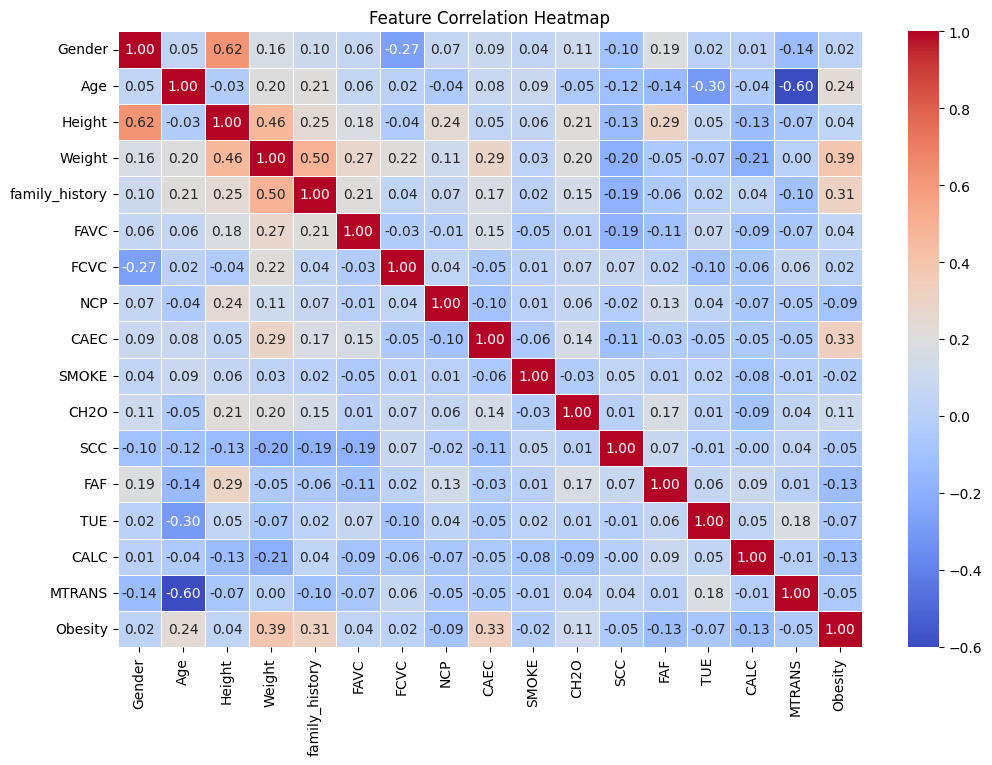

In [ ]:
# Compute correlation matrix
correlation_matrix = df.corr()

# Plot heatmap
plt.figure(figsize=(12, 8))
sns.heatmap(correlation_matrix, annot=True, cmap="coolwarm", fmt=".2f", linewidths=0.5)
plt.title("Feature Correlation Heatmap")
plt.show()


In [ ]:
from sklearn.model_selection import train_test_split

# Define features (X) and target variable (y)
X = df.drop(columns=['Obesity'])
y = df['Obesity']

# Split into training (80%) and testing (20%) sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# Display dataset sizes
X_train.shape, X_test.shape, y_train.shape, y_test.shape


((1688, 16), (423, 16), (1688,), (423,))

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

# Train Logistic Regression model
log_reg = LogisticRegression(max_iter=500, random_state=42)
log_reg.fit(X_train, y_train)

# Predictions
y_pred_log_reg = log_reg.predict(X_test)

# Evaluate Logistic Regression
log_reg_results = {
    "Accuracy": accuracy_score(y_test, y_pred_log_reg),
    "Precision": precision_score(y_test, y_pred_log_reg, average="weighted"),
    "Recall": recall_score(y_test, y_pred_log_reg, average="weighted"),
    "F1 Score": f1_score(y_test, y_pred_log_reg, average="weighted")
}

log_reg_results


{'Accuracy': 0.8723404255319149,
 'Precision': 0.871899071815315,
 'Recall': 0.8723404255319149,
 'F1 Score': 0.8702432765207173}

In [ ]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.linear_model import LogisticRegression # Importing LogisticRegression
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

# Assuming X_train, y_train, X_test, y_test are already defined from a previous cell

# Train Logistic Regression model (Moved from a previous cell)
log_reg = LogisticRegression(max_iter=500, random_state=42)
log_reg.fit(X_train, y_train)

# Predictions (Moved from a previous cell)
y_pred_log_reg = log_reg.predict(X_test)

# Evaluate Logistic Regression (Moved from a previous cell)
log_reg_results = {
    "Accuracy": accuracy_score(y_test, y_pred_log_reg),
    "Precision": precision_score(y_test, y_pred_log_reg, average="weighted"),
    "Recall": recall_score(y_test, y_pred_log_reg, average="weighted"),
    "F1 Score": f1_score(y_test, y_pred_log_reg, average="weighted")
}


# Initialize models
decision_tree = DecisionTreeClassifier(random_state=42)
random_forest = RandomForestClassifier(n_estimators=100, random_state=42)
gradient_boost = GradientBoostingClassifier(n_estimators=100, random_state=42)

# Train models
decision_tree.fit(X_train, y_train)
random_forest.fit(X_train, y_train)
gradient_boost.fit(X_train, y_train)

# Predictions
y_pred_dt = decision_tree.predict(X_test)
y_pred_rf = random_forest.predict(X_test)
y_pred_gb = gradient_boost.predict(X_test)

# Evaluate models
model_results = {
    "Logistic Regression": log_reg_results, # Now log_reg_results is defined
    "Decision Tree": {
        "Accuracy": accuracy_score(y_test, y_pred_dt),
        "Precision": precision_score(y_test, y_pred_dt, average="weighted"),
        "Recall": recall_score(y_test, y_pred_dt, average="weighted"),
        "F1 Score": f1_score(y_test, y_pred_dt, average="weighted"),
    },
    "Random Forest": {
        "Accuracy": accuracy_score(y_test, y_pred_rf),
        "Precision": precision_score(y_test, y_pred_rf, average="weighted"),
        "Recall": recall_score(y_test, y_pred_rf, average="weighted"),
        "F1 Score": f1_score(y_test, y_pred_rf, average="weighted"),
    },
    "Gradient Boosting": {
        "Accuracy": accuracy_score(y_test, y_pred_gb),
        "Precision": precision_score(y_test, y_pred_gb, average="weighted"),
        "Recall": recall_score(y_test, y_pred_gb, average="weighted"),
        "F1 Score": f1_score(y_test, y_pred_gb, average="weighted"),
    },
}

# Convert to DataFrame for better visualization
model_results_df = pd.DataFrame(model_results).T

# Display results
model_results_df

,Accuracy,Precision,Recall,F1 Score
Logistic Regression,0.872340,0.871899,0.872340,0.870243
Decision Tree,0.917258,0.920615,0.917258,0.918246
Random Forest,0.952719,0.956282,0.952719,0.953367
Gradient Boosting,0.959811,0.962781,0.959811,0.960318


<Figure size 1000x600 with 0 Axes>

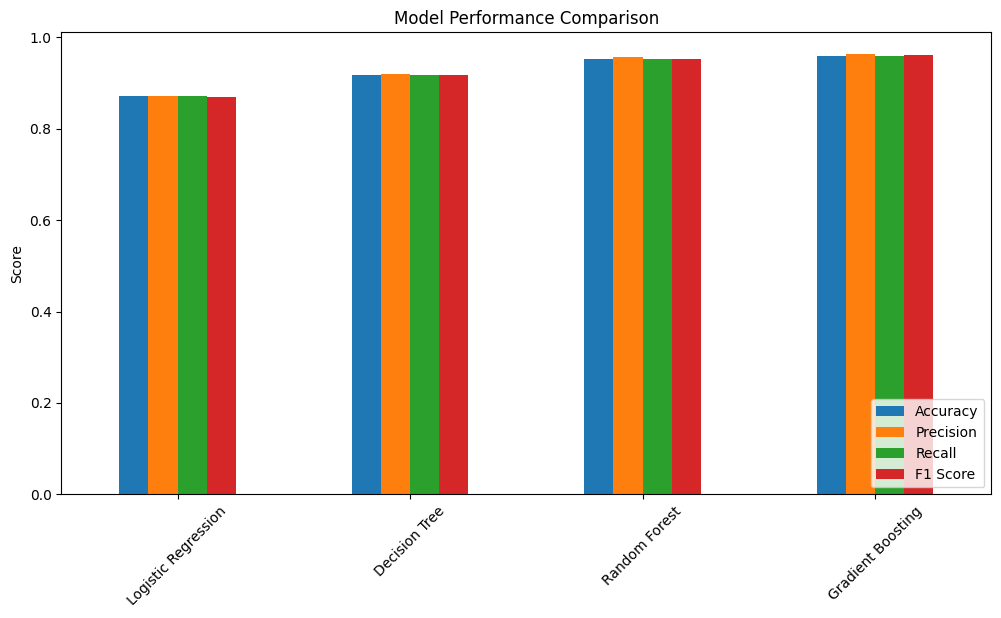

In [ ]:
# Plot model performance comparison
plt.figure(figsize=(10, 6))
model_results_df.plot(kind='bar', figsize=(12, 6), rot=0)
plt.title("Model Performance Comparison")
plt.ylabel("Score")
plt.xticks(rotation=45)
plt.legend(loc='lower right')
plt.show()


In [ ]:
import warnings
warnings.filterwarnings('ignore')

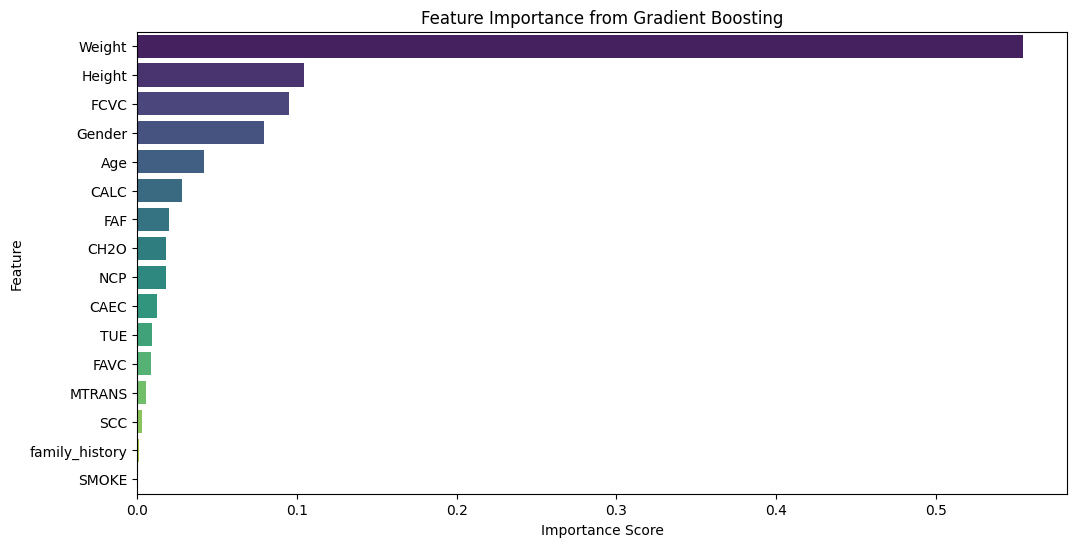

In [ ]:
# Extract feature importances from the Gradient Boosting model
feature_importances = gradient_boost.feature_importances_

# Create a DataFrame for better visualization
feature_importance_df = pd.DataFrame({
    "Feature": X.columns,
    "Importance": feature_importances
}).sort_values(by="Importance", ascending=False)

# Display feature importance table
feature_importance_df

# Plot feature importance
plt.figure(figsize=(12, 6))
sns.barplot(x=feature_importance_df["Importance"], y=feature_importance_df["Feature"], palette="viridis")
plt.xlabel("Importance Score")
plt.ylabel("Feature")
plt.title("Feature Importance from Gradient Boosting")
plt.show()


In [ ]:
from sklearn.model_selection import GridSearchCV

# Define hyperparameter grid for Gradient Boosting
param_grid = {
    'n_estimators': [100, 200],
    'learning_rate': [0.05, 0.1],
    'max_depth': [3, 5],
    'subsample': [0.8, 1.0]
}

# Initialize GridSearchCV
grid_search = GridSearchCV(GradientBoostingClassifier(random_state=42), param_grid, cv=5, scoring='accuracy', n_jobs=-1)

# Perform grid search on training data
grid_search.fit(X_train, y_train)

# Best hyperparameters
best_params = grid_search.best_params_
best_params


{'learning_rate': 0.1, 'max_depth': 5, 'n_estimators': 200, 'subsample': 1.0}

In [ ]:
# Train Gradient Boosting with best parameters
optimized_gb = GradientBoostingClassifier(
    learning_rate=0.1,
    max_depth=5,
    n_estimators=200,
    subsample=1.0,
    random_state=42
)

optimized_gb.fit(X_train, y_train)

# Predictions
y_pred_opt_gb = optimized_gb.predict(X_test)

# Evaluate Optimized Model
optimized_results = {
    "Accuracy": accuracy_score(y_test, y_pred_opt_gb),
    "Precision": precision_score(y_test, y_pred_opt_gb, average="weighted"),
    "Recall": recall_score(y_test, y_pred_opt_gb, average="weighted"),
    "F1 Score": f1_score(y_test, y_pred_opt_gb, average="weighted")
}

print("Optimized Gradient Boosting Performance:")
print(optimized_results)


Optimized Gradient Boosting Performance:
{'Accuracy': 0.9621749408983451, 'Precision': 0.9645850603297413, 'Recall': 0.9621749408983451, 'F1 Score': 0.9624973577687409}


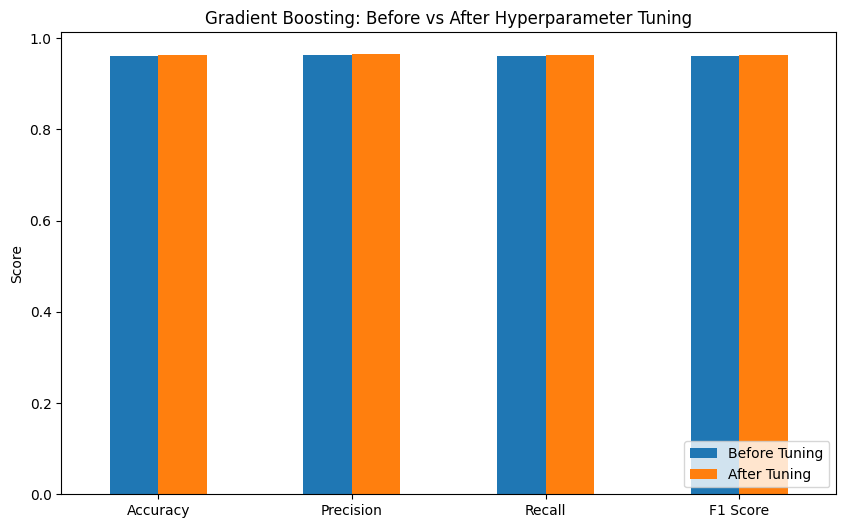

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd

# Compare previous best model (before tuning) with optimized model
comparison_results = pd.DataFrame({
    "Before Tuning": model_results["Gradient Boosting"],
    "After Tuning": optimized_results
})

# Plot comparison
comparison_results.plot(kind='bar', figsize=(10, 6), rot=0)
plt.title("Gradient Boosting: Before vs After Hyperparameter Tuning")
plt.ylabel("Score")
plt.legend(loc='lower right')
plt.show()


PermutationExplainer explainer: 424it [04:23,  1.56it/s]


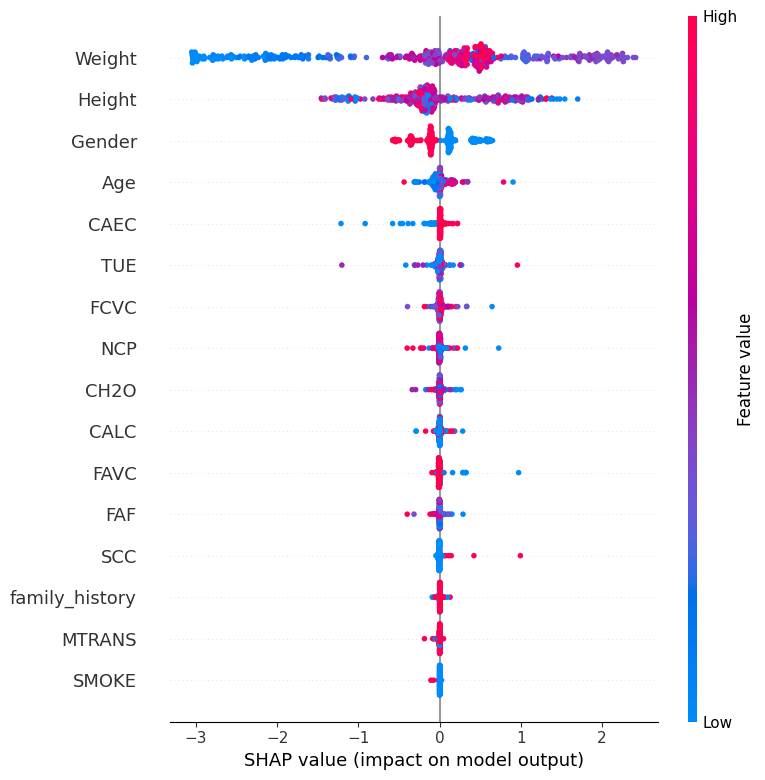

In [ ]:
import shap

# Use Permutation Explainer for models that SHAP TreeExplainer does not support
explainer = shap.Explainer(optimized_gb.predict, X_train)

# Compute SHAP values
shap_values = explainer(X_test)

# SHAP Summary Plot
shap.summary_plot(shap_values, X_test)
